## Librerías.

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


In [3]:
# Configuramos direcciones.
data_dir = os.path.join(project_path, 'data/binary')
path_base = os.path.join(project_path, 'models/celeba_base.h5')

In [4]:
# Creamos los generadores.
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2)

# Generador de entrenamiento.
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training',
    shuffle=True)

# Generador de validación.
valid_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation',
    shuffle=False)

Found 83 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [16]:
# Cargamos el modelo preentrenado.
base_model = tf.keras.models.load_model(path_base)

# Creamos el extractor de características.
feature_extractor = tf.keras.Sequential(base_model.layers[:8])

feature_extractor.trainable = False

# Añadimos el mejor clasificador.
inputs = layers.Input(shape=(224, 224, 3))
x = feature_extractor(inputs)
x = layers.Flatten()(x)
x = layers.Dense(120, activation='relu', kernel_regularizer=regularizers.l2(0.013))(x)
x = layers.Dropout(.6)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=inputs, outputs=output)

In [17]:
# Compilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [18]:
# Vemos la arquitectura del modelo.
print("Arquitectura del Modelo:")
model.summary()

Arquitectura del Modelo:


Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 12, 12, 128)    │       240,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │     2,211,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,452,913 (9.36 MB)

 Trainable params: 2,212,081 (8.44 MB)

 Non-trainable params: 240,832 (940.75 KB)

In [19]:
# Entrenamos.
ruta_mejor_modelo = os.path.join(project_path, 'models/mi_reconocedor_1.h5')

early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    filepath=ruta_mejor_modelo,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max')

history_final = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=50,
    callbacks=[early_stopping, checkpoint],
    verbose=1)

Epoch 1/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.5927 - loss: 3.6859

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 562ms/step - accuracy: 0.5943 - loss: 3.6682 - val_accuracy: 0.6500 - val_loss: 3.3400
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7621 - loss: 3.2156

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.7639 - loss: 3.2080 - val_accuracy: 0.8500 - val_loss: 2.9722
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.7766 - loss: 2.8719 - val_accuracy: 0.7000 - val_loss: 2.6773
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - accuracy: 0.8931 - loss: 2.5450 - val_accuracy: 0.7500 - val_loss: 2.4198
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.9217 - loss: 2.2627 - val_accuracy: 0.6000 - val_loss: 2.2337
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.9311 - loss: 2.0222 - val_accuracy: 0.6000 - val_loss: 2.0307
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - accuracy: 0.9329 - loss: 1.8449 - val_accuracy: 0.6500 - val_loss: 1.8857
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - accuracy: 0.9610 - loss: 1.6349 - val_accuracy: 0.7000 - val_loss: 1.7631
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step - accuracy: 0.9719 - loss: 1.4674 - val_accuracy: 0.6500 - val_

Gráficas guardadas en: /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/training_metrics.png


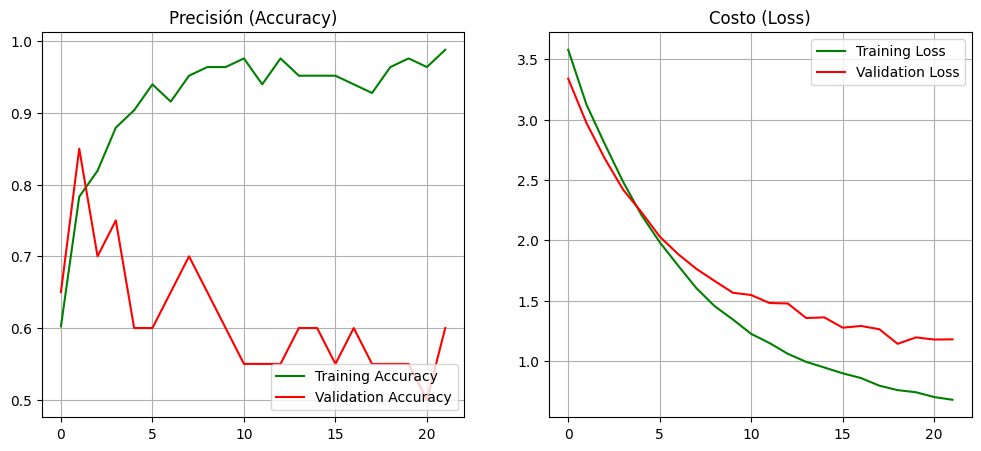

In [20]:
# Gráficas de costo y presición.
acc = history_final.history['accuracy']
val_acc = history_final.history['val_accuracy']
loss = history_final.history['loss']
val_loss = history_final.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de Accuracy.
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, color='green', label='Training Accuracy')
plt.plot(epochs_range, val_acc, color='r', label='Validation Accuracy')
plt.title('Precisión (Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica de Loss (Costo).
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, color='green', label='Training Loss')
plt.plot(epochs_range, val_loss, color='r', label='Validation Loss')
plt.title('Costo (Loss)')
plt.legend(loc='upper right')
plt.grid(True)

imagen_metrics = os.path.join(project_path, 'training_metrics.png')
plt.savefig(imagen_metrics)
print(f"Gráficas guardadas en: {imagen_metrics}")

plt.show()